# Agentic RAG with CrewAI


This notebook demonstrates how to build an **Agentic Retrieval-Augmented Generation (RAG)** system using the `CrewAI` framework. It includes two agents (Router and Retriever), three tools (Web Search, PDF Search, and Generation), and a coordinated workflow (Crew).

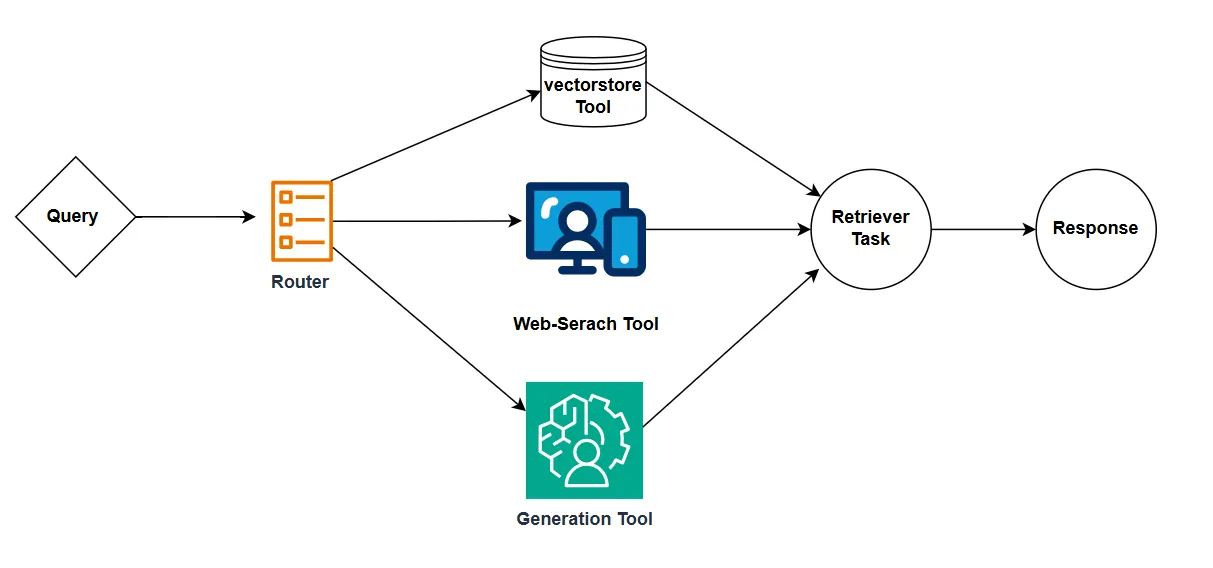

##CrewAI


**CrewAI** is a Python-based framework designed to facilitate the creation of **agentic workflows** for Large Language Models (LLMs).  
It allows developers to build multi-agent systems that can **plan, act, retrieve, generate, and collaborate** to solve complex tasks. CrewAI introduces a structured approach to orchestrating LLMs with tools, tasks, and agents, making AI applications more modular and interpretable.

---

## Core Concepts

1. **Agent**
   - An autonomous LLM-powered entity that can reason, make decisions, and execute actions.
   - Defined by:
     - **Role**: What the agent is responsible for.
     - **Goal**: What the agent aims to achieve.
     - **Backstory**: Context and instructions guiding the agent's reasoning.
     - **Tools & Memory**: Resources it can use and historical knowledge it can retain.

2. **Task**
   - A unit of work assigned to an agent.
   - Contains:
     - **Description**: Instructions for the agent.
     - **Expected Output**: Defines what kind of response is required.
     - **Agent Assignment**: Which agent executes this task.
     - **Context & Tools**: Optional inputs from other tasks or external resources.

3. **Tool**
   - A resource or utility that agents can use to complete tasks.
   - Examples:
     - Web search APIs
     - PDF retrieval
     - LLM-based text generation

4. **Crew**
   - A collection of agents and tasks that coordinate to solve a workflow.
   - The crew manages dependencies between tasks, tool usage, and task execution order.

---

## Key Advantages

- **Modular Design**: Each agent and task is self-contained, allowing easier debugging and scaling.
- **Flexible Integration**: Agents can access external tools (vector stores, APIs, databases) for retrieval-augmented generation (RAG).
- **Agentic RAG**: Unlike traditional RAG that just retrieves and generates, CrewAI enables agents to **reason about which tool to use**, orchestrate multiple steps, and dynamically plan actions.
- **Transparency**: Each task and agent has defined roles and expected outputs, making the decision-making process more interpretable.

---

## Example Use Cases

- **Knowledge Retrieval**: Answering domain-specific questions by combining PDF/vector search and LLM generation.
- **Customer Support Automation**: Multi-agent systems that can retrieve FAQ answers, fetch live data, and provide context-aware responses.
- **Workflow Orchestration**: Coordinating multiple LLM agents to perform multi-step reasoning tasks.


In [ ]:
# Install dependencies
!pip install crewai crewai_tools langchain_community langchain_huggingface sentence-transformers langchain_openai qdrant-client gdown

In [ ]:
import gdown
url = 'https://drive.google.com/file/d/1f-X_cbCcJG0JrJl2FsCNceuA6POKjnXm/view?usp=drive_link'
output_path = '.env'
gdown.download(url, output_path, quiet=False,fuzzy=True)

Downloading...
From: https://drive.google.com/uc?id=1f-X_cbCcJG0JrJl2FsCNceuA6POKjnXm
To: /content/.env
100%|██████████| 181/181 [00:00<00:00, 535kB/s]


'.env'

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv('OPENAI_API_KEY')

In [ ]:
import os
from langchain_community.utilities import GoogleSerperAPIWrapper
from crewai_tools import PDFSearchTool
from crewai.tools import BaseTool
from pydantic import Field
from crewai import Agent, Task, Crew, LLM

# Set API keys
# NOTE: load SERPER_API_KEY from your .env file instead of hardcoding it here.
# The previous hardcoded value had a 'tvly-' prefix, which is a Tavily API key
# format, not a Serper (serper.dev) key -- double check which service you're
# actually using and set the matching env var name in your .env file
# (SERPER_API_KEY for serper.dev, TAVILY_API_KEY if you meant Tavily).
os.environ['SERPER_API_KEY'] = os.getenv('SERPER_API_KEY', '')
os.environ['OPENAI_API_KEY'] = api_key


In [ ]:
# Load the LLM
# CrewAI's Agent.llm field expects a model-name string or a crewai.LLM
# instance (LiteLLM-backed) -- it no longer accepts a LangChain ChatOpenAI
# object directly, which is what caused the earlier ValidationError.
llm = LLM(
    model="gpt-4",
    temperature=0.1,
    max_tokens=1000,
    api_key=os.getenv('OPENAI_API_KEY'),
)


In this example, we will use a research paper on hate speech detection, utilizing a language model (LLM) for understanding. We will download the paper from the web, then store it as a PDF in the runtime environment. This will allow us to process the paper for answering questions related to it. The embeddings of the paper’s contents will be stored in a vector store for efficient searching later on

In [ ]:
# Download a sample PDF (hate speech research paper)
import requests

pdf_url = 'https://arxiv.org/pdf/2405.01577'
response = requests.get(pdf_url)
with open('hatespeech.pdf', 'wb') as f:
    f.write(response.content)

In our example, we have two agents:

1. Routing Agent: This agent decides whether a question should be answered using the vector store (for research papers) or by searching the web (for current events or general knowledge).
2. Retrieval Agent: This agent retrieves relevant information from the vector store when the question relates to a research paper, by searching the stored embeddings for the most relevant details.

These agents work together to ensure accurate and efficient answers based on the type of question asked.

In [ ]:
# Define Agents
def log_step(step):
    print(f"[STEP] {step}")

Router_Agent = Agent(
    role='Router',
    goal='Route user question to a vectorstore or web search or generation',
    backstory=(
        'You are an expert at routing a user question to a vectorstore or web search. '
        'Use the vectorstore for questions on hate speech or fine-tuning of LLM. '
        'Use web-search for recent topics. Use generation for general queries.'
    ),
    verbose=True,
    allow_delegation=False,
    llm=llm,
    step_callback=log_step,
)

Retriever_Agent = Agent(
    role='Retriever',
    goal='Retrieve relevant information based on the router decision',
    backstory='You are a retriever agent that uses provided tools to answer questions.',
    verbose=True,
    allow_delegation=False,
    llm=llm,
    step_callback=log_step,
)


Define the Tool:

In our system, we use several tools to help provide answers based on different sources of information:

1. Generation Tool: This tool uses a language model (LLM) to generate answers for general questions. When a question doesn’t fit with a research paper or current event, the generation tool creates a response by drawing on its trained knowledge base
2. Web Search Tool: This tool is responsible for searching the web to find up-to-date answers for questions related to recent events, news, or any topic where real-time information is needed. It fetches relevant data from online sources.
PDF Search Tool: This tool is part of the 3.3. Retrieval-Augmented Generation (RAG) process. It searches for specific information within a PDF file (like the research paper we’re using) to extract relevant sections or details needed to answer questions based on that document.

These tools work together to ensure that questions are answered from the most appropriate source — whether it’s a PDF document, the web, or generated by the LLM.

In [ ]:
# Define Tools
class SearchTool(BaseTool):
    name: str = 'Search'
    description: str = 'Useful for finding current information from the web.'
    search: GoogleSerperAPIWrapper = Field(default_factory=GoogleSerperAPIWrapper)

    def _run(self, query: str) -> str:
        return self.search.run(query)

class GenerationTool(BaseTool):
    name: str = 'Generation'
    description: str = 'Useful for general queries answered by the LLM.'

    def _run(self, query: str) -> str:
        # crewai.LLM uses .call(), not the LangChain-style .invoke()
        return llm.call(query)

web_search_tool = SearchTool()
generation_tool = GenerationTool()
pdf_search_tool = PDFSearchTool(pdf='hatespeech.pdf')


In our example, we have two tasks:

1. Router Task (By Router Agent): The Router Agent determines whether the question should be answered using the PDF Search Tool, Web Search Tool, or Generation Tool based on the question’s type.
2. Retriever Task (By Retriever Agent, Using Context from Router Task, Tools: Web Search, PDF Search, and Generation): The Retriever Agent uses the context from the Router Task to fetch or generate the answer using the appropriate tools (web, PDF, or LLM).

In short, the Router Task directs the question, and the Retriever Task gets the answer using the right tools.

***Complete the following TASK:***

1. Identify the **retriever_task**.
2. Add agent -  Retriever_Agent
3. Add the context - router_task
4. Add the tools into it - pdf_search_tool, web_search_tool, generation_tool

In [ ]:
# Define Tasks
router_task = Task(
    description=(
        'Analyse the question {question} and decide if it requires a vectorstore search, web search, or generation. '
        "Return only 'vectorstore', 'websearch', or 'generate'."
    ),
    expected_output='One word: vectorstore, websearch, or generate.',
    agent=Router_Agent,
)

retriever_task = Task(
    description=(
        'Based on the router decision, retrieve or generate the answer for {question}. '
        'Use pdf_search_tool for vectorstore, web_search_tool for websearch, and generation_tool for generation.'
    ),
    expected_output='Concise final answer.',
    agent=Retriever_Agent,
    context=[router_task],
    tools=[pdf_search_tool, web_search_tool, generation_tool],
)

In our usecase , we define the Crew by assigning specific tasks to the corresponding agents. The task list and agent list help structure the workflow, ensuring each agent performs its designated role efficiently.

***Complete the following TASK:***

1. Identify the **rag_crew**.
2. Add agents -  Router_Agent, Retriever_Agentt
3. Add the tasks - router_task, retriever_task

In [ ]:
# Define Crew
rag_crew = Crew(
    agents=[Router_Agent, Retriever_Agent],
    tasks=[router_task, retriever_task],
    verbose=True,
    output_log_file="crew_run.json",  # writes the full run trace to a file
)

# Run example (async) -- kickoff_async returns a coroutine, so it must be awaited.
# Jupyter/Colab kernels support top-level await inside a cell.
question = 'What is LLM fine-tuning?'
result = await rag_crew.kickoff_async(inputs={'question': question})
print('Question:', question)
print('Result:', result)


In [ ]:
question = 'what is global warming'
result = await rag_crew.kickoff_async(inputs={'question': question})
print('Question:', question)
print('Result:', result)
